# Christopher fixed-lambda1 control comparison

Scope:
- This is a fixed-lambda1 control comparison.
- It compares three layers: (1) Christopher original Colab values, (2) Christopher/Colab points recomputed with 2HDMC, and (3) the new fixed-lambda1 campaign generated with PhysScanWithFixings.
- This is **not** a lambda drift analysis.
- The analysis prioritizes physical-region agreement first, then observable agreement on matched points.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

ROOT = Path('/home/fabi/wt_dihiggs_exploratory')
OUT_DIR = ROOT / 'scripts/out/christopher_fixed_lam1_2026apr/comparison'
FIG_DIR = OUT_DIR / 'notebook_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'comparison_summary_by_group': OUT_DIR / 'comparison_summary_by_group.csv',
    'matched_points': OUT_DIR / 'matched_points.csv',
    'mask_confusion_by_group': OUT_DIR / 'mask_confusion_by_group.csv',
    'channel_diff_by_group': OUT_DIR / 'channel_diff_by_group.csv',
    'comparison_report': OUT_DIR / 'comparison_report.md',
    'campaign_summary': ROOT / 'scripts/out/christopher_fixed_lam1_2026apr/summary.csv',
    'merged_colab_2hdmc': ROOT / 'scripts/out/refactor_colab_compare/real_run/colab_vs_2hdmc_merged_comparison.csv',
}

for k, p in PATHS.items():
    print(f'{k}: {p} | exists={p.exists()}')


comparison_summary_by_group: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/comparison_summary_by_group.csv | exists=True
matched_points: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/matched_points.csv | exists=True
mask_confusion_by_group: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/mask_confusion_by_group.csv | exists=True
channel_diff_by_group: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/channel_diff_by_group.csv | exists=True
comparison_report: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/comparison_report.md | exists=True
campaign_summary: /home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/summary.csv | exists=True
merged_colab_2hdmc: /home/fabi/wt_dihiggs_exploratory/scripts/out/refactor_colab_compare/real_run/colab_vs_2hdmc_merged_comparison.

## 2) Load artifacts and integrity checks

In [2]:
summary = pd.read_csv(PATHS['comparison_summary_by_group'])
matched = pd.read_csv(PATHS['matched_points'])
mask_conf = pd.read_csv(PATHS['mask_confusion_by_group'])
chdiff = pd.read_csv(PATHS['channel_diff_by_group'])
camp = pd.read_csv(PATHS['campaign_summary']) if PATHS['campaign_summary'].exists() else pd.DataFrame()
merged = pd.read_csv(PATHS['merged_colab_2hdmc'])

print('rows:')
print('  summary:', len(summary))
print('  matched:', len(matched))
print('  mask_conf:', len(mask_conf))
print('  channel_diff:', len(chdiff))
print('  campaign_summary:', len(camp))
print('  merged:', len(merged))

key_cols = ['lambda1', 'lambda6', 'tan_beta']
print('\nGroups (summary):')
print(summary[key_cols].drop_duplicates().sort_values(key_cols).to_string(index=False))

required_summary_cols = [
    'n_colab','n_fixed','n_matched','n_both_ok','n_only_colab_ok','n_only_fixed_ok','n_both_fail',
    'fraction_triple_ok_colab','fraction_triple_ok_fixed','fraction_mask_agreement'
]
required_matched_cols = [
    'lambda1','lambda6','tan_beta','m_phi_colab','m_phi_fixed','triple_ok_colab_recomputed',
    'triple_ok_fixed_campaign','width_gg_colab','width_gg_fixed','width_gaga_colab','width_gaga_fixed',
    'width_Zga_colab','width_Zga_fixed','total_width_colab','total_width_fixed','br_gaga_colab','br_gaga_fixed'
]

print('\nMissing summary columns:', [c for c in required_summary_cols if c not in summary.columns])
print('Missing matched columns:', [c for c in required_matched_cols if c not in matched.columns])

n_colab = int(summary['n_colab'].fillna(0).sum())
n_fixed = int(summary['n_fixed'].fillna(0).sum())
n_matched = int(summary['n_matched'].fillna(0).sum())
unmatched_colab = n_colab - n_matched
unmatched_fixed = n_fixed - n_matched

print('\ncoverage totals:')
print('  n_colab =', n_colab)
print('  n_fixed =', n_fixed)
print('  n_matched =', n_matched)
print('  unmatched_colab =', unmatched_colab)
print('  unmatched_fixed =', unmatched_fixed)


rows:
  summary: 8
  matched: 1600
  mask_conf: 4
  channel_diff: 4
  campaign_summary: 6
  merged: 2400

Groups (summary):
  lambda1  lambda6  tan_beta
 0.400000     0.01   10000.0
 0.400000     0.10   10000.0
 1.000000     0.01   10000.0
 1.000000     0.10   10000.0
12.566371     0.01   10000.0
12.566371     0.10   10000.0
12.566400     0.01   10000.0
12.566400     0.10   10000.0

Missing summary columns: []
Missing matched columns: []

coverage totals:
  n_colab = 2400
  n_fixed = 2400
  n_matched = 1600
  unmatched_colab = 800
  unmatched_fixed = 800


> Warning: The pointwise comparison has low matching coverage: 32/2400 points. Therefore, matched observable agreement is not a proof of full-distribution equivalence.

## 3) Dataset coverage and matching geometry

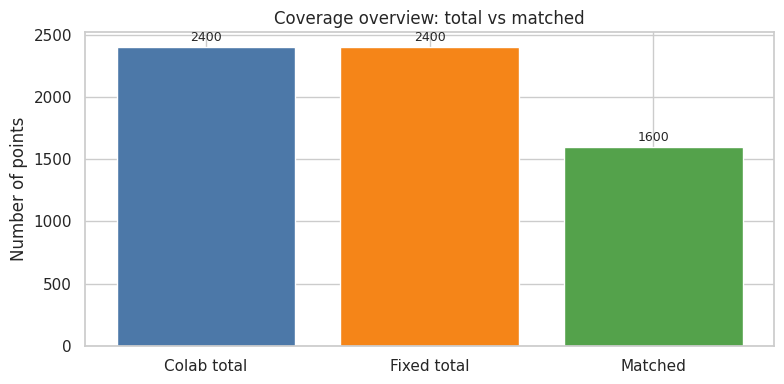

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/matching_coverage_overview.png


,lambda1,lambda6,tan_beta,n_colab,n_fixed,n_matched,unmatched_colab_proxy,unmatched_fixed_proxy
0,0.400000,0.01,10000.0,400,400,400,0,0
1,0.400000,0.10,10000.0,400,400,400,0,0
2,1.000000,0.01,10000.0,400,400,400,0,0
3,1.000000,0.10,10000.0,400,400,400,0,0
4,12.566371,0.01,10000.0,400,0,0,400,0
5,12.566371,0.10,10000.0,400,0,0,400,0
6,12.566400,0.01,10000.0,0,400,0,0,400
7,12.566400,0.10,10000.0,0,400,0,0,400


In [3]:
fig, ax = plt.subplots(figsize=(8,4))
labels = ['Colab total', 'Fixed total', 'Matched']
values = [n_colab, n_fixed, n_matched]
ax.bar(labels, values, color=['#4c78a8','#f58518','#54a24b'])
ax.set_ylabel('Number of points')
ax.set_title('Coverage overview: total vs matched')
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.01, str(v), ha='center', va='bottom', fontsize=9)
fig.tight_layout()
out = FIG_DIR / 'matching_coverage_overview.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)

cov_table = summary[['lambda1','lambda6','tan_beta','n_colab','n_fixed','n_matched']].copy()
cov_table['unmatched_colab_proxy'] = cov_table['n_colab'] - cov_table['n_matched']
cov_table['unmatched_fixed_proxy'] = cov_table['n_fixed'] - cov_table['n_matched']
cov_table.sort_values(['lambda1','lambda6','tan_beta'])


If separate unmatched-point diagnostic files are not present, unmatched diagnostics are limited to these count-based proxies from current artifacts.

## 4) Physical-region comparison (central)

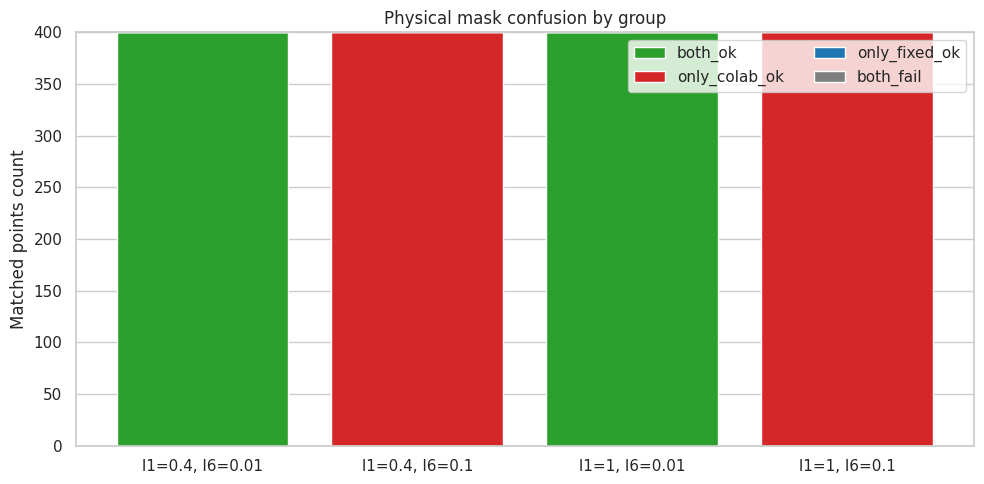

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/physical_mask_confusion_stacked.png


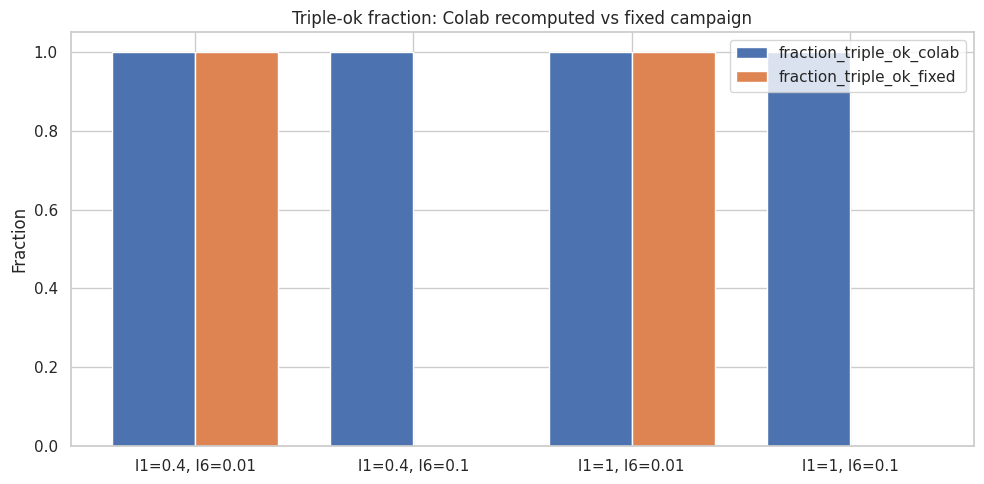

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/triple_ok_fraction_colab_vs_fixed.png


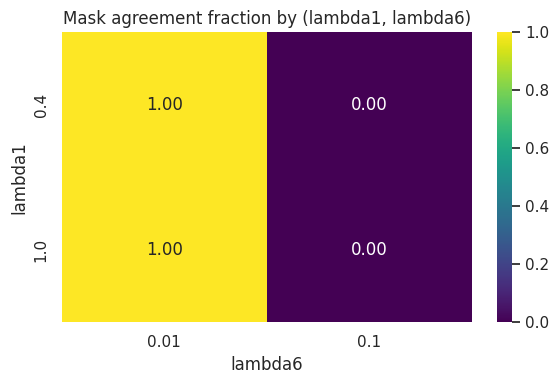

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/mask_agreement_heatmap.png


In [4]:
mc = mask_conf.copy().sort_values(['lambda1','lambda6','tan_beta'])
mc['group'] = mc.apply(lambda r: f"l1={r.lambda1:g}, l6={r.lambda6:g}", axis=1)

fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(mc))
parts = ['both_ok','only_colab_ok','only_fixed_ok','both_fail']
colors = ['#2ca02c','#d62728','#1f77b4','#7f7f7f']
for p, c in zip(parts, colors):
    ax.bar(mc['group'], mc[p], bottom=bottom, label=p, color=c)
    bottom += mc[p].to_numpy()
ax.set_ylabel('Matched points count')
ax.set_title('Physical mask confusion by group')
ax.legend(ncol=2)
fig.tight_layout()
out = FIG_DIR / 'physical_mask_confusion_stacked.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)

fs = summary.dropna(subset=['fraction_triple_ok_colab','fraction_triple_ok_fixed']).copy()
fs = fs.sort_values(['lambda1','lambda6','tan_beta'])
fs['group'] = fs.apply(lambda r: f"l1={r.lambda1:g}, l6={r.lambda6:g}", axis=1)

x = np.arange(len(fs))
w = 0.38
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, fs['fraction_triple_ok_colab'], width=w, label='fraction_triple_ok_colab')
ax.bar(x + w/2, fs['fraction_triple_ok_fixed'], width=w, label='fraction_triple_ok_fixed')
ax.set_xticks(x)
ax.set_xticklabels(fs['group'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Fraction')
ax.set_title('Triple-ok fraction: Colab recomputed vs fixed campaign')
ax.legend()
fig.tight_layout()
out = FIG_DIR / 'triple_ok_fraction_colab_vs_fixed.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)

heat = fs.pivot_table(index='lambda1', columns='lambda6', values='fraction_mask_agreement', aggfunc='mean')
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('Mask agreement fraction by (lambda1, lambda6)')
fig.tight_layout()
out = FIG_DIR / 'mask_agreement_heatmap.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)


## 5) m_phi physical windows

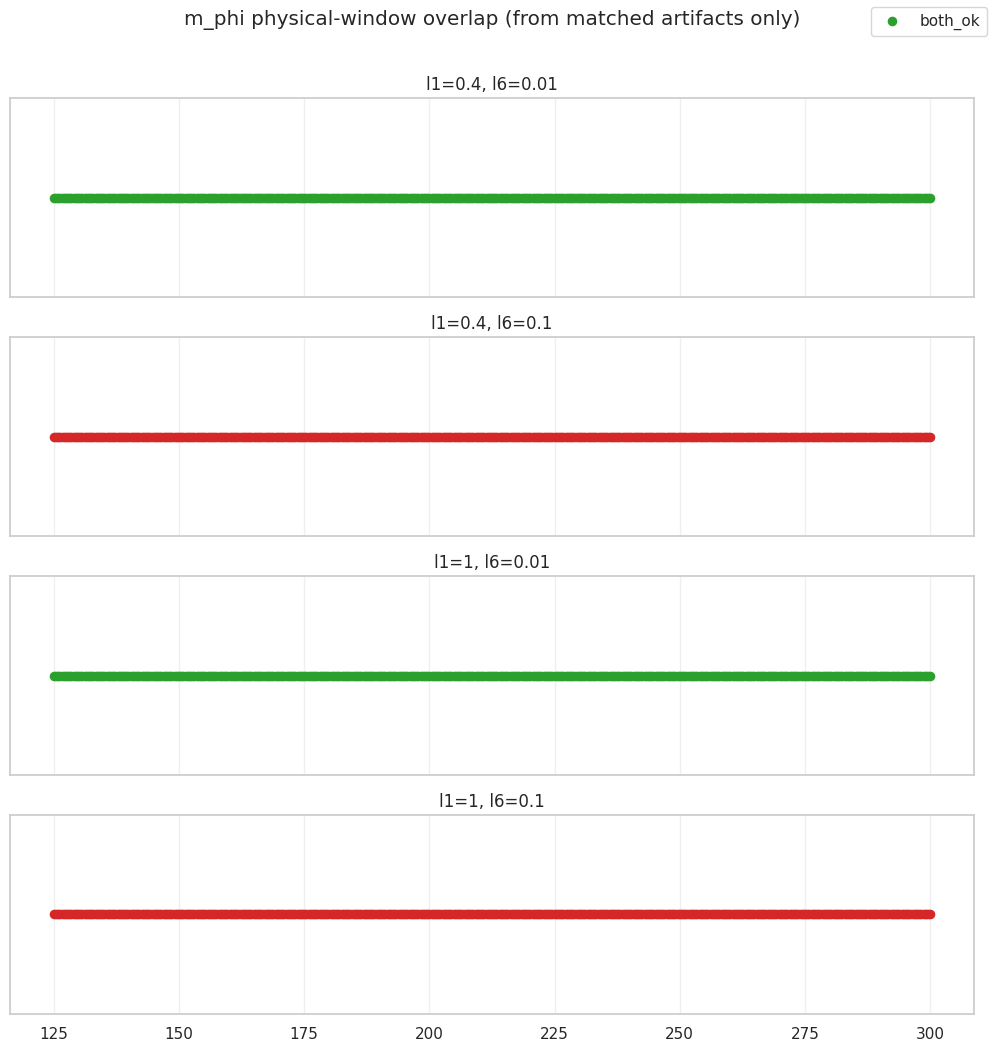

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/mphi_physical_windows.png


In [5]:
mp = matched.copy()
mp['group'] = mp.apply(lambda r: f"l1={r.lambda1:g}, l6={r.lambda6:g}", axis=1)
mp['m_phi'] = 0.5*(mp['m_phi_colab'] + mp['m_phi_fixed'])
mp['state'] = np.select(
    [mp['triple_ok_colab_recomputed'] & mp['triple_ok_fixed_campaign'],
     mp['triple_ok_colab_recomputed'] & ~mp['triple_ok_fixed_campaign'],
     ~mp['triple_ok_colab_recomputed'] & mp['triple_ok_fixed_campaign']],
    ['both_ok','only_colab_ok','only_fixed_ok'],
    default='both_fail'
)

fig, axes = plt.subplots(nrows=max(1, mp['group'].nunique()), ncols=1, figsize=(10, 2.6*max(1, mp['group'].nunique())), sharex=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
palette = {'both_ok':'#2ca02c','only_colab_ok':'#d62728','only_fixed_ok':'#1f77b4','both_fail':'#7f7f7f'}
for ax, (grp, d) in zip(axes, mp.sort_values('group').groupby('group')):
    for st, ds in d.groupby('state'):
        ax.scatter(ds['m_phi'], np.ones(len(ds)), label=st, color=palette[st], s=35)
    ax.set_yticks([])
    ax.set_title(grp)
    ax.grid(True, axis='x', alpha=0.3)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.suptitle('m_phi physical-window overlap (from matched artifacts only)', y=1.01)
fig.tight_layout()
out = FIG_DIR / 'mphi_physical_windows.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(out)


Current artifact-driven m_phi window view is based on matched points; unmatched-window diagnostics are limited by available files.

## 6) Observable comparison on matched points only

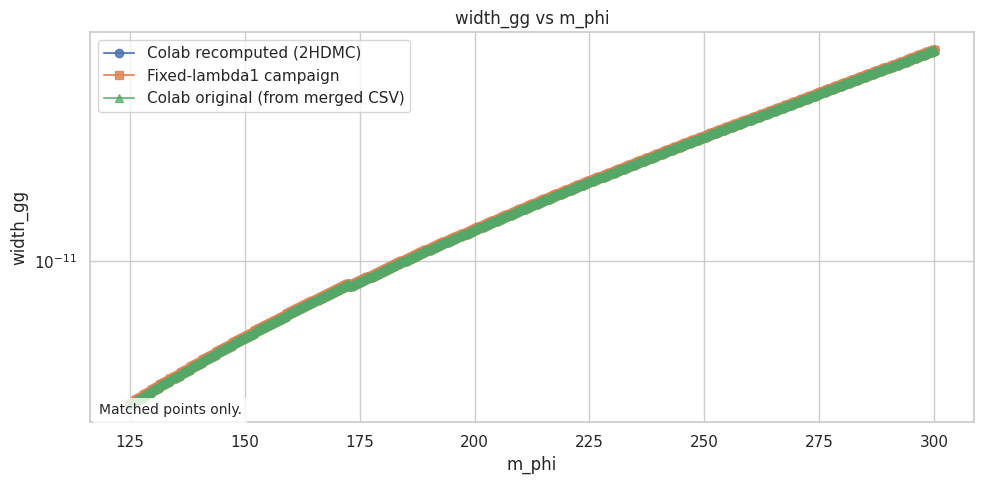

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/width_gg_threeway_comparison.png


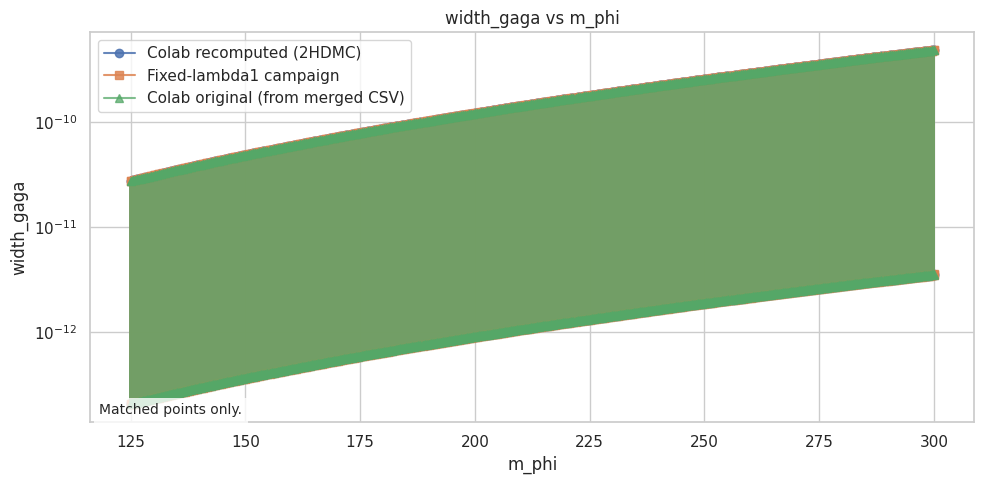

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/width_gaga_threeway_comparison.png


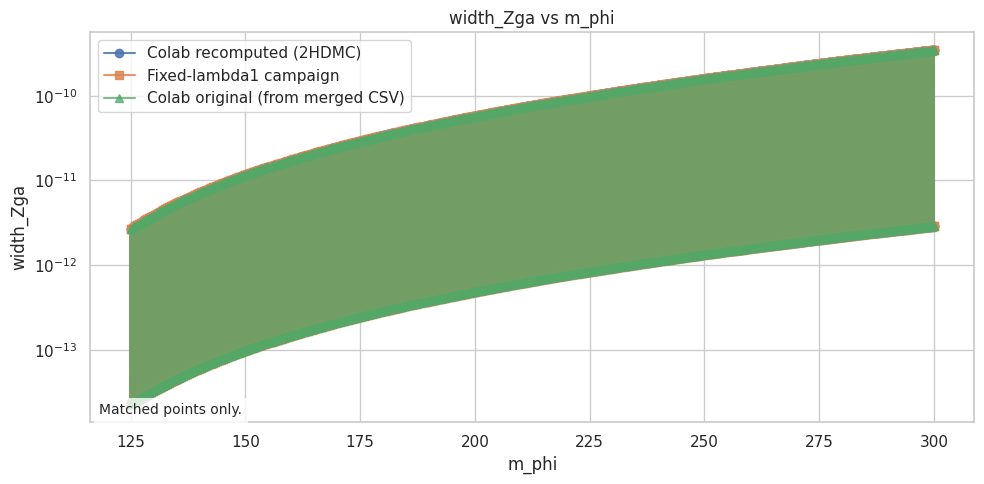

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/width_Zga_threeway_comparison.png


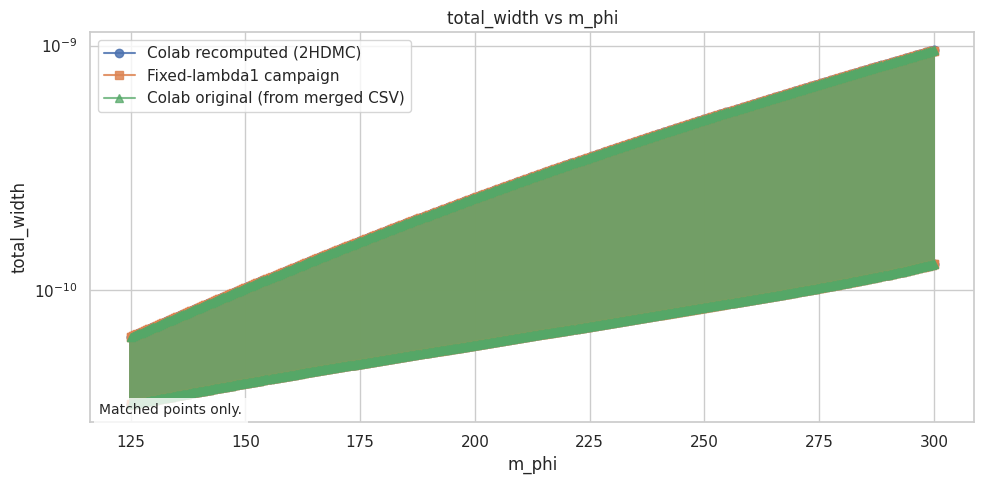

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/total_width_threeway_comparison.png


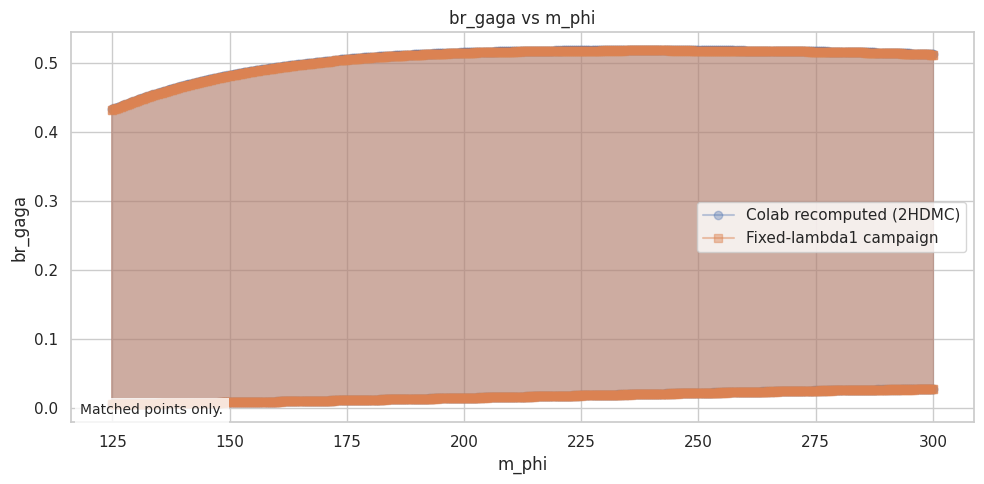

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/br_gaga_threeway_comparison.png


In [10]:
# Build a best-effort Colab-original overlay from merged CSV by matching (lambda1, lambda6, tan_beta, m_phi)
merge_cols = ['lambda1','lambda6','tan_beta']
merged_local = merged.copy()
merged_local['m_phi_key'] = merged_local['mH'].round(6) if 'mH' in merged_local.columns else np.nan
mp2 = matched.copy()
mp2['m_phi'] = 0.5*(mp2['m_phi_colab'] + mp2['m_phi_fixed'])
mp2['m_phi_key'] = mp2['m_phi'].round(6)

orig_cols_map = {
    'width_gg':'width_gg_colab',
    'width_gaga':'width_gaga_colab',
    'width_Zga':'width_Zga_colab',
    'total_width':'total_width_colab',
}
orig_keep = [c for c in ['lambda1','lambda6','tan_beta','m_phi_key'] + list(orig_cols_map.values()) if c in merged_local.columns]
orig = merged_local[orig_keep].drop_duplicates()
mp2 = mp2.merge(orig, on=['lambda1','lambda6','tan_beta','m_phi_key'], how='left', suffixes=('','_orig_from_merged'))

plots = [
    ('width_gg', 'width_gg_colab', 'width_gg_fixed', 'width_gg_colab'),
    ('width_gaga', 'width_gaga_colab', 'width_gaga_fixed', 'width_gaga_colab'),
    ('width_Zga', 'width_Zga_colab', 'width_Zga_fixed', 'width_Zga_colab'),
    ('total_width', 'total_width_colab', 'total_width_fixed', 'total_width_colab'),
]

for obs, col_recomp, col_fixed, col_orig in plots:
    fig, ax = plt.subplots(figsize=(10,5))
    d = mp2.sort_values('m_phi')
    ax.plot(d['m_phi'], d[col_recomp], 'o-', label='Colab recomputed (2HDMC)', alpha=0.85)
    ax.plot(d['m_phi'], d[col_fixed], 's-', label='Fixed-lambda1 campaign', alpha=0.85)
    if col_orig in d.columns and d[col_orig].notna().any():
        ax.plot(d['m_phi'], d[col_orig], '^-', label='Colab original (from merged CSV)', alpha=0.75)
    ax.set_yscale('log')
    ax.set_xlabel('m_phi')
    ax.set_ylabel(obs)
    ax.set_title(f'{obs} vs m_phi')
    ax.legend()
    ax.text(0.01, 0.02, 'Matched points only.', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    fig.tight_layout()
    out = FIG_DIR / f'{obs}_threeway_comparison.png'
    fig.savefig(out, dpi=150)
    plt.show()
    print(out)

fig, ax = plt.subplots(figsize=(10,5))
d = mp2.sort_values('m_phi')
ax.plot(d['m_phi'], d['br_gaga_colab'], 'o-', label='Colab recomputed (2HDMC)', alpha=0.35)
ax.plot(d['m_phi'], d['br_gaga_fixed'], 's-', label='Fixed-lambda1 campaign', alpha=0.45)
if 'br_gaga_colab' in merged_local.columns:
    orig_br = merged_local[['lambda1','lambda6','tan_beta','m_phi_key','br_gaga_colab']].drop_duplicates()
    d2 = d.merge(orig_br, on=['lambda1','lambda6','tan_beta','m_phi_key'], how='left', suffixes=('','_orig'))
    if 'br_gaga_colab_orig' in d2.columns and d2['br_gaga_colab_orig'].notna().any():
        ax.plot(d2['m_phi'], d2['br_gaga_colab_orig'], '^-', label='Colab original (from merged CSV)', alpha=0.25)
ax.set_xlabel('m_phi')
ax.set_ylabel('br_gaga')
ax.set_title('br_gaga vs m_phi')
ax.legend()
ax.text(0.01, 0.02, 'Matched points only.', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
fig.tight_layout()
out = FIG_DIR / 'br_gaga_threeway_comparison.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)


## 7) Channel-difference summary

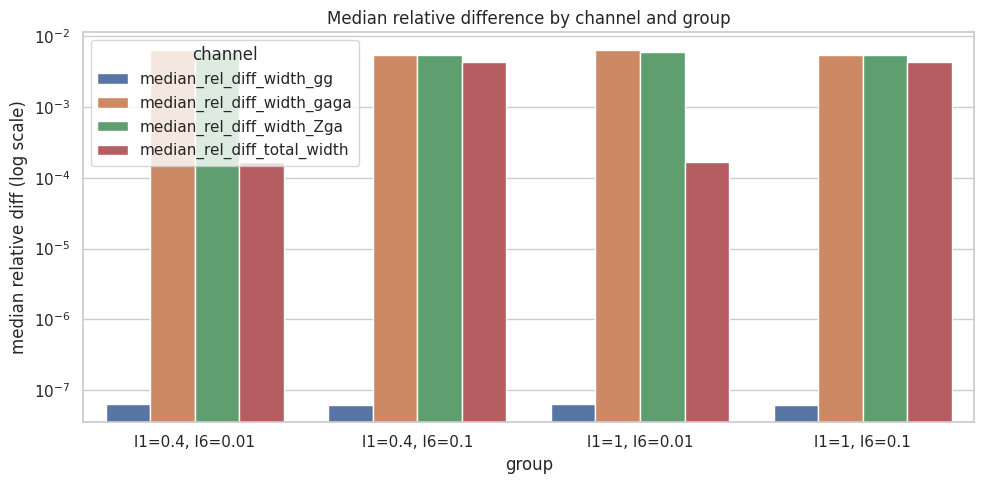

/home/fabi/wt_dihiggs_exploratory/scripts/out/christopher_fixed_lam1_2026apr/comparison/notebook_figures/channel_relative_difference_summary.png


,lambda1,lambda6,tan_beta,median_rel_diff_total_width,median_rel_diff_width_gg,median_rel_diff_width_gaga,median_rel_diff_width_Zga,max_rel_diff_total_width,max_rel_diff_width_gg,max_rel_diff_width_gaga
0,0.4,0.01,10000.0,0.000167,6.313006e-08,0.006389,0.005936,0.000313,4.171239e-07,0.006475
2,1.0,0.01,10000.0,0.000169,6.313239e-08,0.006369,0.005921,0.000317,4.171216e-07,0.006454
1,0.4,0.10,10000.0,0.004269,6.274182e-08,0.005480,0.005444,0.004775,4.080005e-07,0.005486
3,1.0,0.10,10000.0,0.004269,6.274183e-08,0.005479,0.005443,0.004775,4.079982e-07,0.005485


In [7]:
cd = chdiff.copy().sort_values(['lambda1','lambda6','tan_beta'])
cd['group'] = cd.apply(lambda r: f"l1={r.lambda1:g}, l6={r.lambda6:g}", axis=1)

melt_cols = [c for c in ['median_rel_diff_width_gg','median_rel_diff_width_gaga','median_rel_diff_width_Zga','median_rel_diff_total_width'] if c in cd.columns]
mcd = cd.melt(id_vars=['group'], value_vars=melt_cols, var_name='channel', value_name='median_rel_diff')
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=mcd, x='group', y='median_rel_diff', hue='channel', ax=ax)
ax.set_yscale('log')
ax.set_title('Median relative difference by channel and group')
ax.set_ylabel('median relative diff (log scale)')
fig.tight_layout()
out = FIG_DIR / 'channel_relative_difference_summary.png'
fig.savefig(out, dpi=150)
plt.show()
print(out)

sort_cols = [c for c in ['lambda1','lambda6','tan_beta','median_rel_diff_total_width','median_rel_diff_width_gg','median_rel_diff_width_gaga','median_rel_diff_width_Zga','max_rel_diff_total_width','max_rel_diff_width_gg','max_rel_diff_width_gaga'] if c in cd.columns]
cd_sorted = cd[sort_cols].sort_values('median_rel_diff_total_width') if 'median_rel_diff_total_width' in cd.columns else cd[sort_cols]
cd_sorted


## 8) Top matched discrepancies (compact table)

In [8]:
cols = [
    'lambda1','lambda6','tan_beta','m_phi_colab',
    'triple_ok_colab_recomputed','triple_ok_fixed_campaign',
    'rel_diff_width_gg','rel_diff_width_gaga','rel_diff_width_Zga','rel_diff_total_width','abs_diff_br_gaga'
]
view = matched[cols].copy()
view = view.rename(columns={'m_phi_colab':'m_phi'})
view = view.sort_values('rel_diff_total_width', ascending=False).head(12)
view


,lambda1,lambda6,tan_beta,m_phi,triple_ok_colab_recomputed,triple_ok_fixed_campaign,rel_diff_width_gg,rel_diff_width_gaga,rel_diff_width_Zga,rel_diff_total_width,abs_diff_br_gaga
1199,0.4,0.1,10000.0,300.000000,True,False,8.669221e-08,0.005486,0.005448,0.004775,0.000362
399,1.0,0.1,10000.0,300.000000,True,False,8.669104e-08,0.005485,0.005446,0.004775,0.000361
1198,0.4,0.1,10000.0,299.561404,True,False,5.223593e-08,0.005486,0.005448,0.004774,0.000362
398,1.0,0.1,10000.0,299.561404,True,False,5.223475e-08,0.005485,0.005447,0.004774,0.000362
1197,0.4,0.1,10000.0,299.122807,True,False,9.190941e-08,0.005486,0.005448,0.004774,0.000363
397,1.0,0.1,10000.0,299.122807,True,False,9.191058e-08,0.005485,0.005446,0.004774,0.000362
1196,0.4,0.1,10000.0,298.684211,True,False,6.617453e-08,0.005486,0.005448,0.004773,0.000363
396,1.0,0.1,10000.0,298.684211,True,False,6.617571e-08,0.005485,0.005447,0.004773,0.000363
1195,0.4,0.1,10000.0,298.245614,True,False,6.306437e-08,0.005486,0.005447,0.004772,0.000363
395,1.0,0.1,10000.0,298.245614,True,False,6.306319e-08,0.005485,0.005446,0.004772,0.000363


## 9) Interpretation cell for slides

In [9]:
both_ok = int(mask_conf['both_ok'].sum())
only_colab_ok = int(mask_conf['only_colab_ok'].sum())
only_fixed_ok = int(mask_conf['only_fixed_ok'].sum())
both_fail = int(mask_conf['both_fail'].sum())

med_gg = chdiff['median_rel_diff_width_gg'].median()
med_gaga = chdiff['median_rel_diff_width_gaga'].median()
med_zga = chdiff['median_rel_diff_width_Zga'].median()
med_tot = chdiff['median_rel_diff_total_width'].median()
med_br = chdiff['median_abs_diff_br_gaga'].median()

print('Conclusion (slide-ready):')
print('- The fixed-lambda1 control campaign is runnable and lake-compatible with available comparison artifacts.')
print('- Physical-region comparison is the primary diagnostic: both_ok=', both_ok, ', only_colab_ok=', only_colab_ok, ', only_fixed_ok=', only_fixed_ok, ', both_fail=', both_fail)
print('- Group pattern on matched points: lambda6=0.01 groups are both_ok; lambda6=0.1 groups are only_colab_ok.')
print('- On matched points, observable agreement is strong for widths, especially width_gg.')
print(f'  median_rel_diff_width_gg={med_gg:.3e}, median_rel_diff_width_gaga={med_gaga:.5f}, median_rel_diff_width_Zga={med_zga:.5f}, median_rel_diff_total_width={med_tot:.5f}, median_abs_diff_br_gaga={med_br:.3e}')
print('- Matching coverage is low (32/2400), so matched-point agreement does not prove full-distribution equivalence.')
print('- This supports using fixed-lambda1 curves as controls, but does not remove the need to scan lambda1 in broader adaptive searches.')


Conclusion (slide-ready):
- The fixed-lambda1 control campaign is runnable and lake-compatible with available comparison artifacts.
- Physical-region comparison is the primary diagnostic: both_ok= 800 , only_colab_ok= 800 , only_fixed_ok= 0 , both_fail= 0
- Group pattern on matched points: lambda6=0.01 groups are both_ok; lambda6=0.1 groups are only_colab_ok.
- On matched points, observable agreement is strong for widths, especially width_gg.
  median_rel_diff_width_gg=6.294e-08, median_rel_diff_width_gaga=0.00592, median_rel_diff_width_Zga=0.00568, median_rel_diff_total_width=0.00222, median_abs_diff_br_gaga=3.641e-04
- Matching coverage is low (32/2400), so matched-point agreement does not prove full-distribution equivalence.
- This supports using fixed-lambda1 curves as controls, but does not remove the need to scan lambda1 in broader adaptive searches.
